## 1. Importar Librerías y Carga de Datos

#### Librerías y configuración inicial

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import re

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

#### Cargar fuentes

In [2]:
siniestros = pd.read_excel("https://www.onsv.gob.pe/estaticos/excel/BBDD%20ONSV%20-%20SINIESTROS%20FATALES%202021-2025%20%28preliminar%29.xlsx", header=4)
vehiculos = pd.read_excel("https://www.onsv.gob.pe/estaticos/excel/BBDD%20ONSV%20-%20VEHICULOS%202021-2025%20%28preliminar%29.xlsx", header=4)
personas = pd.read_excel("https://www.onsv.gob.pe/estaticos/excel/BBDD%20ONSV%20-%20PERSONAS%202021-2025%20%28preliminar%29.xlsx", header=4)

fuentes = {"Siniestros": siniestros, "Vehículos": vehiculos, "Personas": personas}

#### Normalizar columnas

In [3]:
def normalizar(text: str, in_ascii: bool = True) -> str:
    """Devuelve un texto sin espacios (se eliminan los del inicio y final; el resto se reemplaza por '_'), 
    en minúsculas y alfanumérico.
    
    text: string que se normalizará

    in_ascii: si es True se convertirá el texto a ASCII, default True"""

    t = text.strip()
    t = t.lower()
    t = t.replace(" ", "_")
    if in_ascii:
        t = unicodedata.normalize("NFKD", t).encode("ascii", "ignore").decode("ascii")
    t = re.sub(r"[^a-zA-z0-9_]", "", t)
    t = re.sub(r"_+", "_", t).strip("_")
    return t

for name, df in fuentes.items():
    print(name.center(100, "-"))
    df.columns = [normalizar(x) for x in df.columns]
    print(df.columns)

---------------------------------------------Siniestros---------------------------------------------
Index(['codigo_siniestro', 'fecha_siniestro', 'hora_siniestro',
       'clase_siniestro', 'cantidad_de_fallecidos', 'cantidad_de_lesionados',
       'cantidad_de_vehiculos_danados', 'departamento', 'provincia',
       'distrito', 'zona', 'tipo_de_via', 'red_vial', 'cod_carretera',
       'coordenadas_latitud', 'coordenadas_longitud', 'condicion_climatica',
       'zonificacion', 'caracteristicas_de_via', 'perfil_longitudinal_via',
       'superficie_de_calzada', 'existe_senal_vertical',
       'clasificacion_de_la_senal_vertical_no_1',
       'clasificacion_de_la_senal_vertical_no_2', 'existe_senal_horizontal',
       'causa_factor_principal', 'causa_especifica'],
      dtype='str')
---------------------------------------------Vehículos----------------------------------------------
Index(['codigo_siniestro', 'codigo_vehiculo', 'departamento', 'provincia',
       'distrito', 'situacion_v

#### Vista inicial

In [4]:
for name, df in fuentes.items():
    print(name.center(100, "-"))
    df.info()

---------------------------------------------Siniestros---------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 9106 entries, 0 to 9105
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   codigo_siniestro                         9106 non-null   str    
 1   fecha_siniestro                          9106 non-null   object 
 2   hora_siniestro                           9106 non-null   str    
 3   clase_siniestro                          9106 non-null   str    
 4   cantidad_de_fallecidos                   9106 non-null   int64  
 5   cantidad_de_lesionados                   9106 non-null   int64  
 6   cantidad_de_vehiculos_danados            6293 non-null   float64
 7   departamento                             9106 non-null   str    
 8   provincia                                9106 non-null   str    
 9   distrito                    

## 2. Tratamiento de Calidad

#### Duplicados exactos, filas y columnas completamente vacías

In [5]:
for name, df in fuentes.items():
    print(name.center(100, "-"))
    no_vacias = df.loc[~df.isna().all(axis=1)] # Se excluye las filas totalmente vacías antes de contar duplicados
    print("Duplicados exactos:", no_vacias.duplicated().sum())
    print("Filas completamente vacías:", df.isna().all(axis=1).sum())
    print("Columnas completamente vacías:", df.isna().all().sum())

---------------------------------------------Siniestros---------------------------------------------
Duplicados exactos: 0
Filas completamente vacías: 0
Columnas completamente vacías: 0
---------------------------------------------Vehículos----------------------------------------------
Duplicados exactos: 0
Filas completamente vacías: 0
Columnas completamente vacías: 0
----------------------------------------------Personas----------------------------------------------
Duplicados exactos: 0
Filas completamente vacías: 0
Columnas completamente vacías: 0


No se elimina ningún dato porque no hay casos.

#### Tratamiento de faltantes

In [6]:
for name, df in fuentes.items():
    print(name.center(100, "-"))
    faltantes = (df.isna().mean()*100).sort_values(ascending=False)
    print("Columnas con faltantes (%):")
    print(faltantes[faltantes > 0])

---------------------------------------------Siniestros---------------------------------------------
Columnas con faltantes (%):
clasificacion_de_la_senal_vertical_no_2    94.135735
clasificacion_de_la_senal_vertical_no_1    85.547990
existe_senal_vertical                      77.860751
existe_senal_horizontal                    77.860751
cantidad_de_vehiculos_danados              30.891720
perfil_longitudinal_via                     4.656271
zonificacion                                4.645289
caracteristicas_de_via                      4.645289
condicion_climatica                         4.645289
superficie_de_calzada                       4.645289
causa_especifica                            0.900505
zona                                        0.417307
cod_carretera                               0.010982
dtype: float64
---------------------------------------------Vehículos----------------------------------------------
Columnas con faltantes (%):
tipo_seguro                45.069867
c

Se eliminarán las siguientes columnas por la cantidad de faltantes y falta de uso significativo para el análisis.

In [7]:
siniestros.drop([
    "clasificacion_de_la_senal_vertical_no_1",
    "clasificacion_de_la_senal_vertical_no_2",
    "existe_senal_vertical",
    "existe_senal_horizontal",
    "cantidad_de_vehiculos_danados"
], axis=1, inplace=True)

#### Transformación de tipos

Como la unidad de análisis será codigo_siniestro, se empezará por tratar esta tabla y luego se tratará solo las columnas de las otras tablas que se integrarán.

In [8]:
siniestros.dtypes

codigo_siniestro               str
fecha_siniestro             object
hora_siniestro                 str
clase_siniestro                str
cantidad_de_fallecidos       int64
cantidad_de_lesionados       int64
departamento                   str
provincia                      str
distrito                       str
zona                           str
tipo_de_via                    str
red_vial                       str
cod_carretera                  str
coordenadas_latitud        float64
coordenadas_longitud        object
condicion_climatica            str
zonificacion                   str
caracteristicas_de_via         str
perfil_longitudinal_via        str
superficie_de_calzada          str
causa_factor_principal         str
causa_especifica               str
dtype: object

Columnas a cambiar de tipo:
- fecha_siniestro
- hora_siniestro
- coordenadas_longitud

In [9]:
siniestros["fecha_siniestro"] = pd.to_datetime(siniestros["fecha_siniestro"], dayfirst=True)
siniestros["hora_siniestro"] = pd.to_datetime(siniestros["hora_siniestro"], format="%H:%M").dt.time
siniestros.loc[siniestros["coordenadas_longitud"].str.contains("°", na=False), "coordenadas_longitud"] = siniestros.loc[siniestros["coordenadas_longitud"].str.contains("°", na=False), "coordenadas_longitud"].str.replace("°", "")
siniestros["coordenadas_longitud"] = pd.to_numeric(siniestros["coordenadas_longitud"])
for i in siniestros.select_dtypes(include=str).columns:
    siniestros[i] = siniestros[i].astype("string")
siniestros.dtypes

codigo_siniestro                   string
fecha_siniestro            datetime64[us]
hora_siniestro                     object
clase_siniestro                    string
cantidad_de_fallecidos              int64
cantidad_de_lesionados              int64
departamento                       string
provincia                          string
distrito                           string
zona                               string
tipo_de_via                        string
red_vial                           string
cod_carretera                      string
coordenadas_latitud               float64
coordenadas_longitud              float64
condicion_climatica                string
zonificacion                       string
caracteristicas_de_via             string
perfil_longitudinal_via            string
superficie_de_calzada              string
causa_factor_principal             string
causa_especifica                   string
dtype: object

#### Estandarizar variables categóricas

In [10]:
def estandarizar_texto(df):
    out = df.copy()
    for col in out.select_dtypes(include=["string"]).columns:
        out[col] = out[col].astype("string").str.strip().str.upper()
        out[col] = out[col].replace("", pd.NA)
    return out


siniestros = estandarizar_texto(siniestros)

Reemplazar valores faltantes según corresponda

In [11]:
for i in siniestros.isna().sum()[siniestros.isna().sum()>0].index:
    print(i.center(50, "-"))
    print(siniestros[i].unique())

-----------------------zona-----------------------
<StringArray>
['RURAL', 'URBANA', <NA>]
Length: 3, dtype: string
------------------cod_carretera-------------------
<StringArray>
[        'LM-671', 'NO CORRESPONDE',        'LI-1150',          'PE-1N',
          'PE-22',         'PE-34B',         'PI-102',          'PE-1S',
          'PE-18',          'PE-5S',
 ...
         'LM-644',         'AY-849',         'SM-656',         'TU-532',
        'CU-1125',         'AR-784',         'HV-680',         'AR-803',
         'SM-552',         'SM-588']
Length: 1045, dtype: string
---------------condicion_climatica----------------
<StringArray>
['DESPEJADO',  'LLUVIOSO',   'SOLEADO',   'NUBLADO',        <NA>,    'NIEBLA',
 'GRANIZADO',    'NEVADO', 'VENTARRÓN']
Length: 9, dtype: string
-------------------zonificacion-------------------
<StringArray>
['RURAL', 'INDUSTRIAL', 'COMERCIAL', <NA>, 'RESIDENCIAL', 'ESCOLAR']
Length: 6, dtype: string
--------------caracteristicas_de_via--------------
<

In [12]:
siniestros["causa_especifica"] = siniestros["causa_especifica"].fillna("NO CUENTA CON CAUSA ESPECIFICA")
for i in siniestros.isna().sum()[siniestros.isna().sum()>0].index:
    siniestros[i] = siniestros[i].fillna("DESCONOCIDO")

#### Verificación final de siniestros

In [13]:
siniestros.info()

<class 'pandas.DataFrame'>
RangeIndex: 9106 entries, 0 to 9105
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   codigo_siniestro         9106 non-null   string        
 1   fecha_siniestro          9106 non-null   datetime64[us]
 2   hora_siniestro           9106 non-null   object        
 3   clase_siniestro          9106 non-null   string        
 4   cantidad_de_fallecidos   9106 non-null   int64         
 5   cantidad_de_lesionados   9106 non-null   int64         
 6   departamento             9106 non-null   string        
 7   provincia                9106 non-null   string        
 8   distrito                 9106 non-null   string        
 9   zona                     9106 non-null   string        
 10  tipo_de_via              9106 non-null   string        
 11  red_vial                 9106 non-null   string        
 12  cod_carretera            9106 non-null   stri

#### Filas que no cumplan criterios establecidos

In [14]:
reglas = []
def agregar_regla(nombre, mascara):
    reglas.append({"regla": nombre, "incumplimientos": int(mascara.fillna(False).sum())})

agregar_regla("Fallecidos >= 1", siniestros["cantidad_de_fallecidos"] < 1)
agregar_regla("Lesionados >= 0", siniestros["cantidad_de_lesionados"] < 0)
agregar_regla("Latitud aproximada Perú (-19 a 0)", ~siniestros["coordenadas_latitud"].between(-19,0))
agregar_regla("Longitud aproximada Perú (-82.5 a -68)", ~siniestros["coordenadas_longitud"].between(-82.5,-68))

pd.DataFrame(reglas)

,regla,incumplimientos
0,Fallecidos >= 1,0
1,Lesionados >= 0,0
2,Latitud aproximada Perú (-19 a 0),0
3,Longitud aproximada Perú (-82.5 a -68),0


#### Outliers

In [15]:
def resumen_outliers_z(df: pd.DataFrame, columnas: list) -> pd.DataFrame:
    filas = []
    for col in columnas:
        media = df[col].mean()
        std = df[col].std()
        li = -3 * std + media
        ls = 3 * std + media
        filas.append({
                    "variable": col,
                    "media": media, 
                    "std": std,
                    "limite_inferior": li,
                    "limite_superior": ls,
                    "max": df[col].max(),
                    "min": df[col].min(),
                    "posibles_outliers": int(((df[col]<li)|(df[col]>ls)).sum())
        })
    return pd.DataFrame(filas)


display(resumen_outliers_z(siniestros, siniestros.select_dtypes(include=["int64"]).columns))

,variable,media,std,limite_inferior,limite_superior,max,min,posibles_outliers
0,cantidad_de_fallecidos,1.192510,0.981405,-1.751704,4.136725,33,1,86
1,cantidad_de_lesionados,0.860641,2.839359,-7.657436,9.378719,71,0,129


Hay valores muy altos; sin embargo, no se eliminará nada, ya que podrían ser casos de accidentes excepcionalmente grandes.

## 3. Integración

#### Preparación

In [16]:
fuentes_agg = {"Vehículos": vehiculos, "Personas": personas}

for name, df in fuentes_agg.items():
    print(name.center(100, "-"))
    df.info()

---------------------------------------------Vehículos----------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 12667 entries, 0 to 12666
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   codigo_siniestro         12667 non-null  str   
 1   codigo_vehiculo          12667 non-null  str   
 2   departamento             12667 non-null  str   
 3   provincia                12667 non-null  str   
 4   distrito                 12667 non-null  str   
 5   situacion_vehiculo       12667 non-null  str   
 6   estado_modalidad         12548 non-null  str   
 7   modalidad_de_transporte  12554 non-null  str   
 8   elemento_transportado    9222 non-null   str   
 9   ambito_servicio          9204 non-null   str   
 10  posee_seguro             10518 non-null  str   
 11  estado_soat              12570 non-null  str   
 12  tipo_seguro              6958 non-null   str   
 13  c

Columnas que se integrarán
- n_vehiculos
- n_con_seguro_vigente
- n_con_citv_vigente
- vehiculo_fugado
- existe_moto
- n_personas
- peaton_involucrado
- edad_promedio
- n_masculino
- n_femenino
- conductor_sin_licencia_vigente
- existe_dosaje_cualitativo_positivo

In [17]:
veh_col_int = ["codigo_siniestro", "codigo_vehiculo", "estado_soat", "estado_citv", "situacion_vehiculo", "vehiculo"]
per_col_int = ["codigo_siniestro", "codigo_persona", "tipo_persona", "edad", "sexo", "estado_licencia", "resultado_del_dosaje_etilico_cualitativo"]

veh_int = vehiculos[veh_col_int]
per_int = personas[per_col_int]

fuentes_agg = {"Vehículos": veh_int, "Personas": per_int}

for name, df in fuentes_agg.items():
    print(name.center(100, "-"))
    df.info()

---------------------------------------------Vehículos----------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 12667 entries, 0 to 12666
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   codigo_siniestro    12667 non-null  str  
 1   codigo_vehiculo     12667 non-null  str  
 2   estado_soat         12570 non-null  str  
 3   estado_citv         12562 non-null  str  
 4   situacion_vehiculo  12667 non-null  str  
 5   vehiculo            12667 non-null  str  
dtypes: str(6)
memory usage: 593.9 KB
----------------------------------------------Personas----------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 25412 entries, 0 to 25411
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   codigo_siniestro                          254

#### Conversión de tipo

In [18]:
per_int["edad"] = pd.to_numeric(per_int["edad"], errors="coerce").astype("Int64")
for name, df in fuentes_agg.items():
    print(name.center(100, "-"))
    df.info()

---------------------------------------------Vehículos----------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 12667 entries, 0 to 12666
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   codigo_siniestro    12667 non-null  str  
 1   codigo_vehiculo     12667 non-null  str  
 2   estado_soat         12570 non-null  str  
 3   estado_citv         12562 non-null  str  
 4   situacion_vehiculo  12667 non-null  str  
 5   vehiculo            12667 non-null  str  
dtypes: str(6)
memory usage: 593.9 KB
----------------------------------------------Personas----------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 25412 entries, 0 to 25411
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   codigo_siniestro                          25412

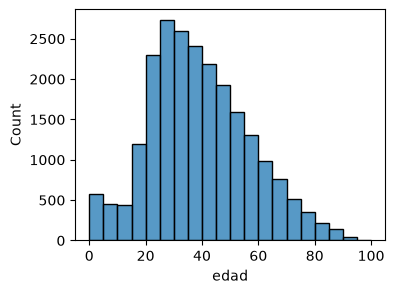

count      22731.0
mean     38.561304
std       17.80961
min            0.0
25%           26.0
50%           37.0
75%           50.0
max          100.0
Name: edad, dtype: Float64

In [19]:
plt.subplots(figsize=(4, 3))
sns.histplot(
    data=per_int,
    x="edad",
    bins=20
)
plt.show()
per_int["edad"].describe()

Como es asimétrica se decide imputar la mediana

In [20]:
edad_median = per_int["edad"].median()
per_int["edad"] = per_int["edad"].fillna(int(edad_median))

#### Faltantes

In [21]:
for name, df in fuentes_agg.items():
    print(name.center(100, "-"))
    for i in df.select_dtypes(str).isna().sum()[df.select_dtypes(str).isna().sum()>0].index:
        print(i.center(50, "-"))
        print(df[i].unique())

---------------------------------------------Vehículos----------------------------------------------
-------------------estado_soat--------------------
<StringArray>
['VIGENTE', 'NO REGISTRA', nan, 'VENCIDO', 'NO APLICA']
Length: 5, dtype: str
-------------------estado_citv--------------------
<StringArray>
['VENCIDO', 'NO REGISTRA', nan, 'NO APLICA', 'VIGENTE']
Length: 5, dtype: str
----------------------------------------------Personas----------------------------------------------
-----------------------sexo-----------------------
<StringArray>
['MASCULINO', 'FEMENINO', 'NO INDICA', nan]
Length: 4, dtype: str
-----------------estado_licencia------------------
<StringArray>
[                           'VIGENTE',                       'NO CONDUCTOR',
                             'FUGADO',                        'NO REGISTRA',
                       'SIN LICENCIA',                                  nan,
                     'NO CORRESPONDE',                            'VENCIDA',
        

In [22]:
veh_int["estado_soat"] = veh_int["estado_soat"].fillna("NO APLICA")
veh_int["estado_citv"] = veh_int["estado_citv"].fillna("NO APLICA")
per_int["sexo"] = per_int["sexo"].fillna("NO INDICA")
per_int["estado_licencia"] = per_int["estado_licencia"].fillna("NO REGISTRA")
per_int["resultado_del_dosaje_etilico_cualitativo"] = per_int["resultado_del_dosaje_etilico_cualitativo"].fillna("DESCONOCIDO")

In [23]:
for name, df in fuentes_agg.items():
    print(name.center(100, "-"))
    df.info()

---------------------------------------------Vehículos----------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 12667 entries, 0 to 12666
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   codigo_siniestro    12667 non-null  str  
 1   codigo_vehiculo     12667 non-null  str  
 2   estado_soat         12667 non-null  str  
 3   estado_citv         12667 non-null  str  
 4   situacion_vehiculo  12667 non-null  str  
 5   vehiculo            12667 non-null  str  
dtypes: str(6)
memory usage: 593.9 KB
----------------------------------------------Personas----------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 25412 entries, 0 to 25411
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   codigo_siniestro                          25412

In [24]:
print(veh_int["vehiculo"].unique())

<StringArray>
[         'CAMIONETA RURAL',         'TRIMOTO PASAJERO',
 'VEHICULO NO IDENTIFICADO',              'MOTOCICLETA',
                   'CAMIÓN',        'CAMIONETA PICK UP',
                'BICICLETA',            'STATION WAGON',
                  'ÓMNIBUS',                'AUTOMÓVIL',
  'REMOLCADOR-SEMIREMOLQUE',                  'MINIBUS',
               'REMOLCADOR',             'SEMIREMOLQUE',
            'TRIMOTO CARGA',                     'OTRO',
   'TRICICLO NO MOTORIZADO',          'CAMIONETA PANEL',
      'TRICICLO MOTORIZADO',                 'BICIMOTO',
    'MOTOCICLETA ELECTRICA',                  'SCOOTER',
                 'REMOLQUE']
Length: 23, dtype: str


## 4. Agregación

In [25]:
veh_agg = veh_int.groupby("codigo_siniestro").agg(
    n_vehiculos=("codigo_vehiculo", "nunique"),
    n_con_seguro_vigente=("estado_soat", lambda s: (s=="VIGENTE").sum()),
    n_con_citv_vigente=("estado_citv", lambda s: (s=="VIGENTE").sum()),
    n_vehiculos_fugados=("situacion_vehiculo", lambda s: (s=="FUGADO").sum()),
    existe_moto=("vehiculo", lambda s: s.isin(["MOTOCICLETA", "MOTOCICLETA ELECTRICA"]).any())
).reset_index()
veh_agg.head()

,codigo_siniestro,n_vehiculos,n_con_seguro_vigente,n_con_citv_vigente,n_vehiculos_fugados,existe_moto
0,A-2021-01-108,2,2,0,0,True
1,A-2021-01-109,1,1,0,0,False
2,A-2021-01-114,1,0,0,0,True
3,A-2021-01-119,1,1,1,0,False
4,A-2021-01-120,2,2,1,0,False


In [26]:
per_agg = per_int.groupby("codigo_siniestro").agg(
    n_personas=("codigo_persona", "nunique"),
    peaton_involucrado=("tipo_persona", lambda s: (s=="PEATÓN").any()),
    edad_promedio=("edad", "mean"),
    n_masculino=("sexo", lambda s: (s=="MASCULINO").sum()),
    n_femenino=("sexo", lambda s: (s=="FEMENINO").sum()),
    existe_conductor_sin_licencia_vigente=("estado_licencia", lambda s: s.isin(["SIN LICENCIA", "VENCIDA", "CANCELADA", "CONDUCTOR INHABILITADO", "ANULADA / CONDUCTOR INHABILITADO", "RETENIDA", "INHABILITADO", "SUSPENDIDA", "CANCELADA / CONDUCTOR INHABILITADO", "CANCELADA / INHABILITADA"]).any()),
    existe_dosaje_cualitativo_positivo=("resultado_del_dosaje_etilico_cualitativo", lambda s: (s=="POSITIVO").any())
).reset_index()
per_agg.head()

,codigo_siniestro,n_personas,peaton_involucrado,edad_promedio,n_masculino,n_femenino,existe_conductor_sin_licencia_vigente,existe_dosaje_cualitativo_positivo
0,A-2021-01-108,2,False,39.5,2,0,False,False
1,A-2021-01-109,2,True,47.0,2,0,True,False
2,A-2021-01-114,1,False,24.0,1,0,True,False
3,A-2021-01-119,1,False,47.0,1,0,False,False
4,A-2021-01-120,2,False,33.5,2,0,True,False


#### Merge

In [27]:
base_int = siniestros.merge(veh_agg, on="codigo_siniestro", how="left").merge(per_agg, on="codigo_siniestro", how="left")
base_int.head()

,codigo_siniestro,fecha_siniestro,hora_siniestro,clase_siniestro,cantidad_de_fallecidos,cantidad_de_lesionados,departamento,provincia,distrito,zona,tipo_de_via,red_vial,cod_carretera,coordenadas_latitud,coordenadas_longitud,condicion_climatica,zonificacion,caracteristicas_de_via,perfil_longitudinal_via,superficie_de_calzada,causa_factor_principal,causa_especifica,n_vehiculos,n_con_seguro_vigente,n_con_citv_vigente,n_vehiculos_fugados,existe_moto,n_personas,peaton_involucrado,edad_promedio,n_masculino,n_femenino,existe_conductor_sin_licencia_vigente,existe_dosaje_cualitativo_positivo
0,A-2021-01-23,2021-01-01,04:40:00,DESPISTE,1,0,LIMA,HUARAL,HUARAL,RURAL,CARRETERA,PROVINCIAL,LM-671,-11.482879,-77.255547,DESPEJADO,RURAL,TRAMO RECTO,PLANA,TROCHA,EN PROCESO DE INVESTIGACIÓN,NO CUENTA CON CAUSA ESPECIFICA,1,1,0,0,False,1,False,21.0,1,0,False,False
1,A-2021-01-248,2021-01-01,05:45:00,DESPISTE,1,3,LIMA,LIMA,PACHACAMAC,URBANA,AVENIDA,URBANO,NO CORRESPONDE,-12.229400,-76.859412,DESPEJADO,INDUSTRIAL,TRAMO RECTO,PLANA,ASFALTADA,IMPRUDENCIA DEL CONDUCTOR,CONDUCIR EN ESTADO DE EBRIEDAD Y/O DROGADICCIÓN,1,0,0,0,False,4,False,29.25,3,1,False,True
2,A-2021-01-38,2021-01-01,06:00:00,ATROPELLO FUGA,2,0,LA LIBERTAD,VIRU,VIRU,URBANA,CARRETERA,PROVINCIAL,LI-1150,-8.414865,-78.754544,DESPEJADO,COMERCIAL,TRAMO RECTO,PLANA,ASFALTADA,EN PROCESO DE INVESTIGACIÓN,NO CUENTA CON CAUSA ESPECIFICA,1,0,0,1,False,2,True,37.5,1,0,False,False
3,A-2021-01-39,2021-01-01,07:00:00,CHOQUE,1,0,LA LIBERTAD,VIRU,VIRU,RURAL,CARRETERA,NACIONAL,PE-1N,-8.432617,-78.772242,DESPEJADO,RURAL,TRAMO RECTO,PLANA,ASFALTADA,IMPRUDENCIA DEL CONDUCTOR,GIRAR IMPRUDENTEMENTE,2,0,0,0,True,3,False,39.666667,2,0,False,False
4,A-2021-01-254,2021-01-01,14:00:00,ATROPELLO,1,1,LIMA,LIMA,VILLA MARIA DEL TRIUNFO,URBANA,AVENIDA,URBANO,NO CORRESPONDE,-12.164406,-76.953426,DESPEJADO,INDUSTRIAL,TRAMO RECTO,PLANA,ASFALTADA,IMPRUDENCIA DEL CONDUCTOR,CONDUCIR EN ESTADO DE EBRIEDAD Y/O DROGADICCIÓN,1,1,0,0,True,2,True,23.0,2,0,False,True


In [28]:
base_int.info()

<class 'pandas.DataFrame'>
RangeIndex: 9106 entries, 0 to 9105
Data columns (total 34 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   codigo_siniestro                       9106 non-null   object        
 1   fecha_siniestro                        9106 non-null   datetime64[us]
 2   hora_siniestro                         9106 non-null   object        
 3   clase_siniestro                        9106 non-null   string        
 4   cantidad_de_fallecidos                 9106 non-null   int64         
 5   cantidad_de_lesionados                 9106 non-null   int64         
 6   departamento                           9106 non-null   string        
 7   provincia                              9106 non-null   string        
 8   distrito                               9106 non-null   string        
 9   zona                                   9106 non-null   string        
 10 

## 5. EDA

#### Distribución de los siniestros por clase de siniestro

C:\Users\erick\AppData\Local\Temp\ipykernel_25392\3698243879.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


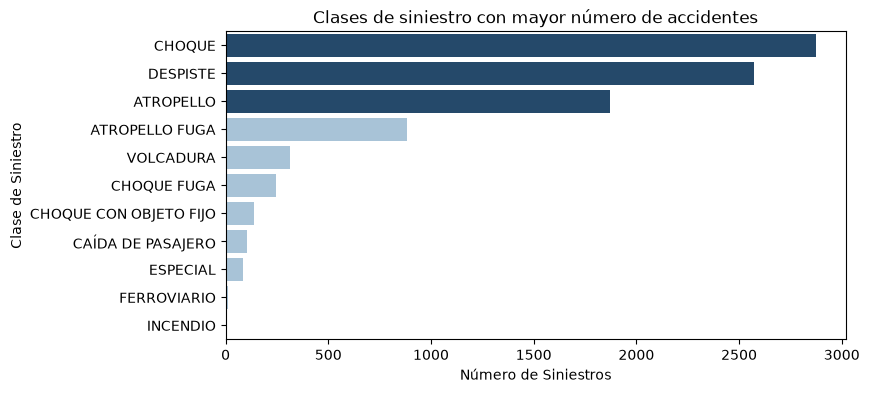

In [29]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(
    data=base_int,
    y='clase_siniestro',
    order=base_int.groupby(by = 'clase_siniestro').codigo_siniestro.agg('count').reset_index().sort_values('codigo_siniestro', ascending=False)['clase_siniestro'],
    palette=["#1a4a75"] * 3 + ["#a0c4df"] * 8,
)
plt.title('Clases de siniestro con mayor número de accidentes')
plt.ylabel('Clase de Siniestro')
plt.xlabel('Número de Siniestros')
plt.show()

Se observa que hay un número considerablemente mayor de siniestros del tipo choque, despiste y atropello con más de 1500 siniestros cada uno, por lo que es posible que los hallazgos no sea tan aplicables al resto de clases de siniestro.

#### Departamentos con más siniestros

C:\Users\erick\AppData\Local\Temp\ipykernel_25392\2516333914.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


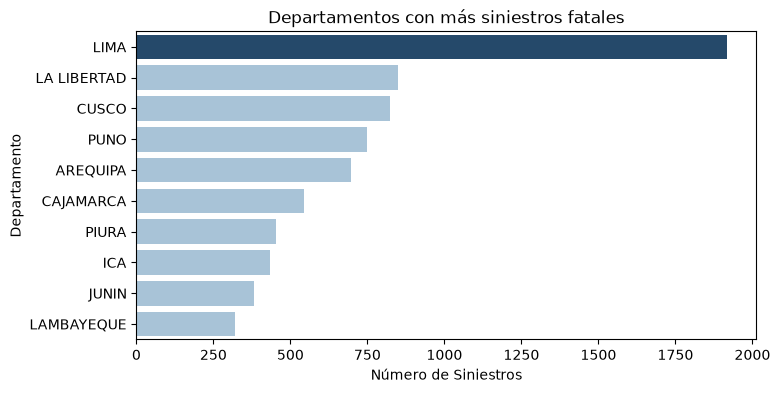

In [30]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(
    data=base_int,
    y='departamento',
    order=base_int.groupby(by = 'departamento').codigo_siniestro.agg('count').reset_index().sort_values('codigo_siniestro', ascending=False)['departamento'].head(10),
    palette=["#1a4a75"] * 1 + ["#a0c4df"] * 9,
)
plt.title('Departamentos con más siniestros fatales')
plt.ylabel('Departamento')
plt.xlabel('Número de Siniestros')
plt.show()

Lima registra la mayor cantidad de siniestros fatales en la base con más de 1750 siniestros. Después aparecen La Libertad y Cusco. Este gráfico muestra conteos absolutos; por eso no permite afirmar que Lima tenga necesariamente un mayor riesgo, ya que no se está ajustando por población, parque vehicular o exposición al tránsito.

#### 

#### Clase de siniestro por zona

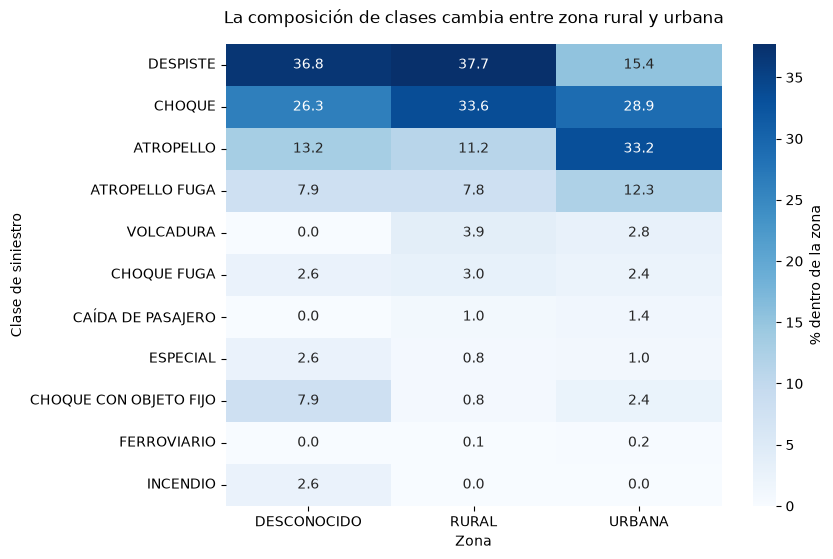

In [31]:
tabla_porcentajes = (
    pd.crosstab(
        index=base_int["clase_siniestro"],
        columns=base_int["zona"],
        normalize="columns",
    )
    * 100
)

tabla_porcentajes = tabla_porcentajes.sort_values(by="RURAL", ascending=False)


plt.figure(figsize=(8, 6))

ax = sns.heatmap(
    tabla_porcentajes,
    annot=True,  
    fmt=".1f", 
    cmap="Blues",  
    cbar_kws={
        "label": "% dentro de la zona"
    }, 
)

plt.title("La composición de clases cambia entre zona rural y urbana", pad=15)
plt.ylabel("Clase de siniestro")
plt.xlabel("Zona")
ax.xaxis.tick_bottom()
plt.show()

Se puede observar que en las zonas rurales hay más despistes (33.6%) mientras que en las zonas urbanas (33.2%) suele haber más atropellos.
No se puede afirmar una causalidad.

## 6. Matriz Analítica

In [32]:
base_int.info()

<class 'pandas.DataFrame'>
RangeIndex: 9106 entries, 0 to 9105
Data columns (total 34 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   codigo_siniestro                       9106 non-null   object        
 1   fecha_siniestro                        9106 non-null   datetime64[us]
 2   hora_siniestro                         9106 non-null   object        
 3   clase_siniestro                        9106 non-null   string        
 4   cantidad_de_fallecidos                 9106 non-null   int64         
 5   cantidad_de_lesionados                 9106 non-null   int64         
 6   departamento                           9106 non-null   string        
 7   provincia                              9106 non-null   string        
 8   distrito                               9106 non-null   string        
 9   zona                                   9106 non-null   string        
 10 

In [33]:
# Se eliminan columnas que no se consideran necesarias para la matriz analítica. Se eliminan las geográficas, ya que la información se puede obtener de las coordendas.
matriz_analit = base_int.drop(["departamento", "provincia", "distrito", "cod_carretera", "zonificacion", "perfil_longitudinal_via", "superficie_de_calzada", "causa_especifica", "condicion_climatica", "caracteristicas_de_via", "tipo_de_via"], axis=1)

# Dividir el dato de hora en madrugada, mañana, tarde y noche y asignarles los números del 1 al 4. 
matriz_analit["hora_siniestro"] = matriz_analit["hora_siniestro"].apply(lambda x: x.hour)
matriz_analit["hora_siniestro"] = pd.cut(matriz_analit["hora_siniestro"], bins=[0, 6, 12, 18, 24], labels=[1, 2, 3, 4], right=False)

# One hot encoding para zona se ignora desconocido (equivalente a que ambos sea 0)
matriz_analit = pd.get_dummies(
    matriz_analit,
    columns=["zona"],
    prefix="zona",
    dtype=int
).drop(["zona_DESCONOCIDO"], axis=1)

# One hot encoding para causa
matriz_analit["causa_factor_principal"] = matriz_analit["causa_factor_principal"].map({
    "EN PROCESO DE INVESTIGACIÓN": "INVESTIGACION",
    "IMPRUDENCIA DEL PEATÓN": "PEATON",
    "INFRAESTRUCTURA Y ENTORNO VIAL": "ENTORNO",
    "IMPRUDENCIA DEL PASAJERO/OCUPANTE": "PASAJERO",
    "IMPRUDENCIA DEL CONDUCTOR": "CONDUCTOR",
    "NEGLIGENCIA DEL CONDUCTOR": "CONDUCTOR",
    "IMPERICIA DEL CONDUCTOR": "CONDUCTOR"
})
matriz_analit = pd.get_dummies(
    matriz_analit,
    columns=["causa_factor_principal"],
    prefix="causa_factor_principal",
    dtype=int
)

# Se codificó red_vial
matriz_analit["red_vial"] = matriz_analit["red_vial"].map({"SIN CLASIFICAR": 0, "URBANO": 1, "PROVINCIAL": 2, "DEPARTAMENTAL": 3, "NACIONAL": 4})

# Codifica valores booleanos 
for i in ["existe_moto", "peaton_involucrado", "existe_conductor_sin_licencia_vigente", "existe_dosaje_cualitativo_positivo"]:
    matriz_analit[i] = matriz_analit[i].astype(int)

matriz_analit.info()
matriz_analit.head()

<class 'pandas.DataFrame'>
RangeIndex: 9106 entries, 0 to 9105
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   codigo_siniestro                       9106 non-null   object        
 1   fecha_siniestro                        9106 non-null   datetime64[us]
 2   hora_siniestro                         9106 non-null   category      
 3   clase_siniestro                        9106 non-null   string        
 4   cantidad_de_fallecidos                 9106 non-null   int64         
 5   cantidad_de_lesionados                 9106 non-null   int64         
 6   red_vial                               9106 non-null   int64         
 7   coordenadas_latitud                    9106 non-null   float64       
 8   coordenadas_longitud                   9106 non-null   float64       
 9   n_vehiculos                            9106 non-null   int64         
 10 

,codigo_siniestro,fecha_siniestro,hora_siniestro,clase_siniestro,cantidad_de_fallecidos,cantidad_de_lesionados,red_vial,coordenadas_latitud,coordenadas_longitud,n_vehiculos,n_con_seguro_vigente,n_con_citv_vigente,n_vehiculos_fugados,existe_moto,n_personas,peaton_involucrado,edad_promedio,n_masculino,n_femenino,existe_conductor_sin_licencia_vigente,existe_dosaje_cualitativo_positivo,zona_RURAL,zona_URBANA,causa_factor_principal_CONDUCTOR,causa_factor_principal_ENTORNO,causa_factor_principal_INVESTIGACION,causa_factor_principal_PASAJERO,causa_factor_principal_PEATON
0,A-2021-01-23,2021-01-01,1,DESPISTE,1,0,2,-11.482879,-77.255547,1,1,0,0,0,1,0,21.0,1,0,0,0,1,0,0,0,1,0,0
1,A-2021-01-248,2021-01-01,1,DESPISTE,1,3,1,-12.229400,-76.859412,1,0,0,0,0,4,0,29.25,3,1,0,1,0,1,1,0,0,0,0
2,A-2021-01-38,2021-01-01,2,ATROPELLO FUGA,2,0,2,-8.414865,-78.754544,1,0,0,1,0,2,1,37.5,1,0,0,0,0,1,0,0,1,0,0
3,A-2021-01-39,2021-01-01,2,CHOQUE,1,0,4,-8.432617,-78.772242,2,0,0,0,1,3,0,39.666667,2,0,0,0,1,0,1,0,0,0,0
4,A-2021-01-254,2021-01-01,3,ATROPELLO,1,1,1,-12.164406,-76.953426,1,1,0,0,1,2,1,23.0,2,0,0,1,0,1,1,0,0,0,0


#### Escalamiento z-score

In [34]:
from sklearn.preprocessing import StandardScaler
estandarizador = StandardScaler()

matriz_z = matriz_analit.copy()
col_escalar = ["cantidad_de_fallecidos", "cantidad_de_lesionados", "n_vehiculos", "n_con_seguro_vigente", "n_con_citv_vigente", "n_vehiculos_fugados", "n_personas", "edad_promedio", "n_masculino", "n_femenino"]

matriz_z[col_escalar] = estandarizador.fit_transform(matriz_z[col_escalar])

print("Sin escalar".center(100, "-"))
display(matriz_analit.head())
print("Escalar Z".center(100, "-"))
display(matriz_z.head())

--------------------------------------------Sin escalar---------------------------------------------


,codigo_siniestro,fecha_siniestro,hora_siniestro,clase_siniestro,cantidad_de_fallecidos,cantidad_de_lesionados,red_vial,coordenadas_latitud,coordenadas_longitud,n_vehiculos,n_con_seguro_vigente,n_con_citv_vigente,n_vehiculos_fugados,existe_moto,n_personas,peaton_involucrado,edad_promedio,n_masculino,n_femenino,existe_conductor_sin_licencia_vigente,existe_dosaje_cualitativo_positivo,zona_RURAL,zona_URBANA,causa_factor_principal_CONDUCTOR,causa_factor_principal_ENTORNO,causa_factor_principal_INVESTIGACION,causa_factor_principal_PASAJERO,causa_factor_principal_PEATON
0,A-2021-01-23,2021-01-01,1,DESPISTE,1,0,2,-11.482879,-77.255547,1,1,0,0,0,1,0,21.0,1,0,0,0,1,0,0,0,1,0,0
1,A-2021-01-248,2021-01-01,1,DESPISTE,1,3,1,-12.229400,-76.859412,1,0,0,0,0,4,0,29.25,3,1,0,1,0,1,1,0,0,0,0
2,A-2021-01-38,2021-01-01,2,ATROPELLO FUGA,2,0,2,-8.414865,-78.754544,1,0,0,1,0,2,1,37.5,1,0,0,0,0,1,0,0,1,0,0
3,A-2021-01-39,2021-01-01,2,CHOQUE,1,0,4,-8.432617,-78.772242,2,0,0,0,1,3,0,39.666667,2,0,0,0,1,0,1,0,0,0,0
4,A-2021-01-254,2021-01-01,3,ATROPELLO,1,1,1,-12.164406,-76.953426,1,1,0,0,1,2,1,23.0,2,0,0,1,0,1,1,0,0,0,0


---------------------------------------------Escalar Z----------------------------------------------


,codigo_siniestro,fecha_siniestro,hora_siniestro,clase_siniestro,cantidad_de_fallecidos,cantidad_de_lesionados,red_vial,coordenadas_latitud,coordenadas_longitud,n_vehiculos,n_con_seguro_vigente,n_con_citv_vigente,n_vehiculos_fugados,existe_moto,n_personas,peaton_involucrado,edad_promedio,n_masculino,n_femenino,existe_conductor_sin_licencia_vigente,existe_dosaje_cualitativo_positivo,zona_RURAL,zona_URBANA,causa_factor_principal_CONDUCTOR,causa_factor_principal_ENTORNO,causa_factor_principal_INVESTIGACION,causa_factor_principal_PASAJERO,causa_factor_principal_PEATON
0,A-2021-01-23,2021-01-01,1,DESPISTE,-0.196169,-0.303128,2,-11.482879,-77.255547,-0.703917,0.120930,-0.850508,-0.379444,0,-0.537216,0,-1.516937,-0.527956,-0.361037,0,0,1,0,0,0,1,0,0
1,A-2021-01-248,2021-01-01,1,DESPISTE,-0.196169,0.753507,1,-12.229400,-76.859412,-0.703917,-1.082554,-0.850508,-0.379444,0,0.362856,0,-0.834131,0.528420,0.217766,0,1,0,1,1,0,0,0,0
2,A-2021-01-38,2021-01-01,2,ATROPELLO FUGA,0.822835,-0.303128,2,-8.414865,-78.754544,-0.703917,-1.082554,-0.850508,2.614678,0,-0.237192,1,-0.151326,-0.527956,-0.361037,0,0,0,1,0,0,1,0,0
3,A-2021-01-39,2021-01-01,2,CHOQUE,-0.196169,-0.303128,4,-8.432617,-78.772242,1.096102,-1.082554,-0.850508,-0.379444,1,0.062832,0,0.027997,0.000232,-0.361037,0,0,1,0,1,0,0,0,0
4,A-2021-01-254,2021-01-01,3,ATROPELLO,-0.196169,0.049084,1,-12.164406,-76.953426,-0.703917,0.120930,-0.850508,-0.379444,1,-0.237192,1,-1.351408,0.000232,-0.361037,0,1,0,1,1,0,0,0,0
